In [1]:
import os
import copy
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V3_Small_Weights
from sklearn.metrics import classification_report, confusion_matrix

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using: cuda


## 2. Configuration


In [2]:
DATASET_ROOT = Path(r"/kaggle/input/datasets/dukzf1v/unified-datasett/Unified_DMS_Dataset_v4")
print(f"Dataset root: {DATASET_ROOT}")

# Verify folders exist
for split in ["train", "val"]:
    p = DATASET_ROOT / split
    assert p.exists(), f"Missing: {p}"
    count = sum(
        len(list((p / c).glob("*.jpg"))) + len(list((p / c).glob("*.png"))) + len(list((p / c).glob("*.jpeg")))
        for c in ["0_Neutral", "1_Anger", "2_Fear", "3_Happiness", "4_Sadness"]
    )
    print(f"  {split}: {count:,} images")

for test_ds_name in ["affectnet", "fer2013", "rafdb"]:
    p = DATASET_ROOT / "test" / test_ds_name
    assert p.exists(), f"Missing: {p}"
    count = sum(
        len(list((p / c).glob("*.jpg"))) + len(list((p / c).glob("*.png"))) + len(list((p / c).glob("*.jpeg")))
        for c in ["0_Neutral", "1_Anger", "2_Fear", "3_Happiness", "4_Sadness"]
    )
    print(f"  test/{test_ds_name}: {count:,} images")

# ── Hyperparameters ────────────────────────────────────────────────────────
CFG = {
    "img_size":       224,
    "batch_size":     64,
    "num_workers":    4,
    "num_classes":    5,                    
    # Phase 1 (backbone frozen)
    "lr_phase1":      3e-4,
    "weight_decay":   1e-4,
    "epochs":         30,
    "patience":       8,
    "unfreeze_after": 5,
    # Phase 2 (full fine-tuning)
    "lr_phase2":      5e-5,
    # LR scheduler
    "lr_factor":      0.5,
    "lr_patience":    3,
    "seed":           42,
    "output_dir":     "/kaggle/working",
    "class_names":    ["Neutral", "Anger", "Fear", "Happiness", "Sadness"],
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])

Dataset root: /kaggle/input/datasets/dukzf1v/unified-datasett/Unified_DMS_Dataset_v4
  train: 44,112 images
  val: 11,033 images
  test/affectnet: 11,271 images
  test/fer2013: 6,000 images
  test/rafdb: 2,419 images


## 3. Data Loading & Augmentation


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
SZ = CFG["img_size"]

train_tf = transforms.Compose([
    transforms.Resize((SZ + 32, SZ + 32)),
    transforms.RandomCrop(SZ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.02),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.02, scale=(0.01, 0.05)),
])

val_tf = transforms.Compose([
    transforms.Resize((SZ, SZ)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(DATASET_ROOT / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DATASET_ROOT / "val",   transform=val_tf)

test_ds_affectnet = datasets.ImageFolder(DATASET_ROOT / "test/affectnet", transform=val_tf)
test_ds_fer2013   = datasets.ImageFolder(DATASET_ROOT / "test/fer2013",   transform=val_tf)
test_ds_rafdb     = datasets.ImageFolder(DATASET_ROOT / "test/rafdb",     transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=CFG["batch_size"],
                      shuffle=True,  num_workers=CFG["num_workers"],
                      pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=CFG["num_workers"],
                      pin_memory=True)

test_dl_affectnet = DataLoader(test_ds_affectnet, batch_size=CFG["batch_size"],
                               shuffle=False, num_workers=CFG["num_workers"],
                               pin_memory=True)
test_dl_fer2013   = DataLoader(test_ds_fer2013,   batch_size=CFG["batch_size"],
                               shuffle=False, num_workers=CFG["num_workers"],
                               pin_memory=True)
test_dl_rafdb     = DataLoader(test_ds_rafdb,     batch_size=CFG["batch_size"],
                               shuffle=False, num_workers=CFG["num_workers"],
                               pin_memory=True)

print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}")
print(f"Test (AffectNet): {len(test_ds_affectnet):,}  |  Test (FER-2013): {len(test_ds_fer2013):,}  |  Test (RAF-DB): {len(test_ds_rafdb):,}")
print(f"Class index map: {train_ds.class_to_idx}")

# ── Class distribution & weights ──────────────────────────────────────────
counts = np.bincount(train_ds.targets)
print(f"Train class counts: {counts}")

# Inverse-frequency weighting
class_weights = torch.tensor(
    1.0 / counts / (1.0 / counts).sum() * CFG["num_classes"],
    dtype=torch.float32
).to(DEVICE)

print(f"Class weights: {class_weights.cpu().numpy().round(3)}")

Train: 44,112  |  Val: 11,033
Test (AffectNet): 11,271  |  Test (FER-2013): 6,000  |  Test (RAF-DB): 2,419
Class index map: {'0_Neutral': 0, '1_Anger': 1, '2_Fear': 2, '3_Happiness': 3, '4_Sadness': 4}
Train class counts: [ 9752  8502  5015 12770  8073]
Class weights: [0.825 0.946 1.604 0.63  0.996]


## 4. Model: MobileNetV3-Large


In [4]:
def build_model(num_classes: int, dropout: float = 0.3) -> nn.Module:
    """MobileNetV3-Small with custom classifier head."""
    model = models.mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)

    # Freeze backbone initially (Phase 1)
    for p in model.features.parameters():
        p.requires_grad_(False)

    # Replace classifier
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=dropout),
        nn.Linear(256, num_classes),
    )
    return model


model = build_model(CFG["num_classes"]).to(DEVICE)

# Count parameters
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 105MB/s]

Total params:     1,076,005
Trainable params: 148,997  (13.8%)


## 5. Training Utilities


In [5]:
def make_optimizer(model, lr: float, weight_decay: float) -> optim.Optimizer:
    """AdamW optimizer over all currently trainable parameters."""
    return optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )

def make_scheduler(optimizer) -> optim.lr_scheduler.ReduceLROnPlateau:
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",           # val_acc (higher = better)
        factor=CFG["lr_factor"],
        patience=CFG["lr_patience"],
    )

def unfreeze_backbone(model):
    """Unfreeze all backbone layers for Phase 2 fine-tuning."""
    for p in model.features.parameters():
        p.requires_grad_(True)
    total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  [Unfreeze] Backbone unfrozen — trainable params: {total_trainable:,}")

def run_epoch(model, loader, criterion, optimizer=None):
    """Run one training or validation epoch."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += len(labels)

    return total_loss / n, correct / n

## 6. Training Loop


In [6]:
# ── Phase 1 setup (backbone frozen) ───────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = make_optimizer(model, lr=CFG["lr_phase1"], weight_decay=CFG["weight_decay"])
scheduler = make_scheduler(optimizer)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc     = 0.0
patience_counter = 0
best_model_wts   = copy.deepcopy(model.state_dict())
phase            = 1   # track current training phase for logging

print("=" * 60)
print("Training MobileNetV3-Small  |  DMS 5-class Emotions")
print("=" * 60)

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    # ── Unfreeze backbone transition ──────────────────────────────────────
    if epoch == CFG["unfreeze_after"] + 1 and phase == 1:
        phase = 2
        print(f"\n{'─'*60}")
        print(f"  Epoch {epoch}: Switching to Phase 2 — Unfreezing backbone")
        unfreeze_backbone(model)

        optimizer = make_optimizer(model, lr=CFG["lr_phase2"],
                                   weight_decay=CFG["weight_decay"])
        scheduler = make_scheduler(optimizer)

        best_val_acc     = 0.0
        patience_counter = 0
        best_model_wts   = copy.deepcopy(model.state_dict())

        # FIX #5 (continued): Tighten label smoothing for Phase 2.
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
        print(f"  Phase 2: lr={CFG['lr_phase2']:.1e}, label_smoothing=0.05")
        print(f"{'─'*60}\n")

    # ── Forward / backward pass ───────────────────────────────────────────
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_dl,   criterion)

    # Step ReduceLROnPlateau once per epoch using val_acc
    scheduler.step(vl_acc)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]["lr"]
    marker  = " ★" if vl_acc > best_val_acc else ""

    print(f"[P{phase}|{epoch:02d}/{CFG['epochs']}] "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | "
          f"lr={lr_now:.2e} | {elapsed:.1f}s{marker}")

    # ── Checkpoint & early stopping ───────────────────────────────────────
    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        patience_counter = 0
        best_model_wts   = copy.deepcopy(model.state_dict())
        torch.save({
            "epoch":        epoch,
            "phase":        phase,
            "model_state":  best_model_wts,
            "val_acc":      best_val_acc,
            "cfg":          CFG,
        }, f"{CFG['output_dir']}/best_mobilenetv3_5class.pth")
    else:
        patience_counter += 1
        if patience_counter >= CFG["patience"]:
            print(f"\nEarly stopping at epoch {epoch}  "
                  f"(best val_acc={best_val_acc:.4f}, phase={phase})")
            break

print(f"\nBest Val Acc: {best_val_acc:.4f}")

Training MobileNetV3-Small  |  DMS 5-class Emotions
[P1|01/30] tr_loss=1.4901 tr_acc=0.3681 | vl_loss=1.4705 vl_acc=0.4032 | lr=3.00e-04 | 216.1s ★
[P1|02/30] tr_loss=1.4115 tr_acc=0.4366 | vl_loss=1.4040 vl_acc=0.4562 | lr=3.00e-04 | 187.1s ★
[P1|03/30] tr_loss=1.3860 tr_acc=0.4590 | vl_loss=1.4362 vl_acc=0.4322 | lr=3.00e-04 | 172.1s
[P1|04/30] tr_loss=1.3696 tr_acc=0.4669 | vl_loss=1.3812 vl_acc=0.4687 | lr=3.00e-04 | 171.4s ★
[P1|05/30] tr_loss=1.3570 tr_acc=0.4768 | vl_loss=1.4391 vl_acc=0.4435 | lr=3.00e-04 | 169.6s

────────────────────────────────────────────────────────────
  Epoch 6: Switching to Phase 2 — Unfreezing backbone
  [Unfreeze] Backbone unfrozen — trainable params: 1,076,005
  Phase 2: lr=5.0e-05, label_smoothing=0.05
────────────────────────────────────────────────────────────

[P2|06/30] tr_loss=1.1678 tr_acc=0.5701 | vl_loss=1.1120 vl_acc=0.5948 | lr=5.00e-05 | 177.0s ★
[P2|07/30] tr_loss=1.0493 tr_acc=0.6393 | vl_loss=1.0365 vl_acc=0.6349 | lr=5.00e-05 | 191.9s

## 7. Training Curves


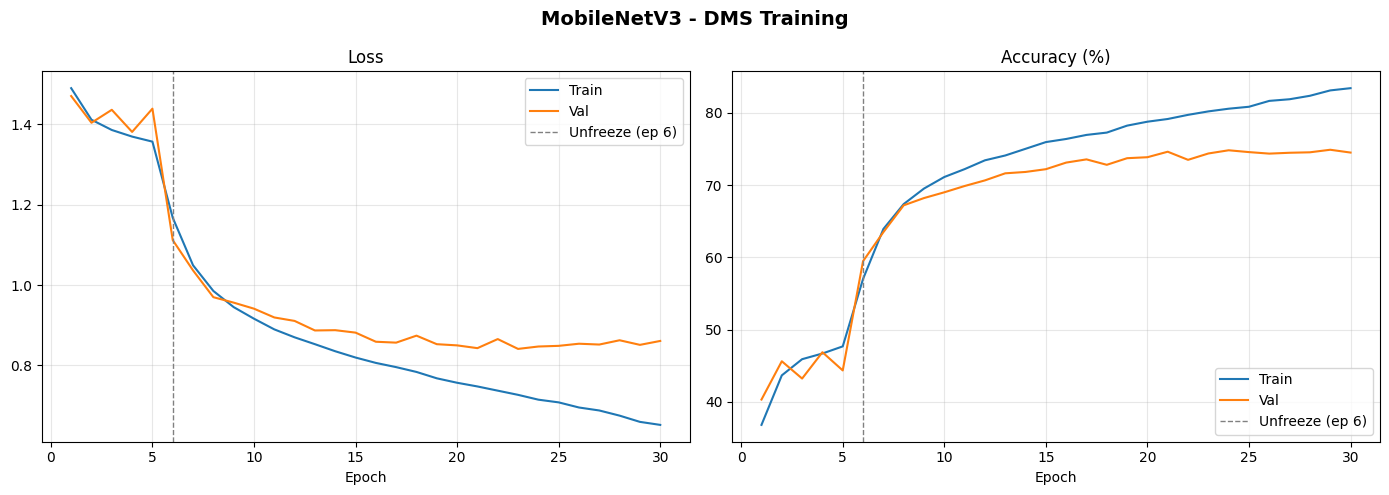

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history["train_loss"]) + 1)

# Draw a vertical line at the unfreeze epoch
unfreeze_ep = CFG["unfreeze_after"] + 1

axes[0].plot(eps, history["train_loss"], label="Train")
axes[0].plot(eps, history["val_loss"],   label="Val")
axes[0].axvline(unfreeze_ep, color="gray", linestyle="--",
                linewidth=1, label=f"Unfreeze (ep {unfreeze_ep})")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eps, [a * 100 for a in history["train_acc"]], label="Train")
axes[1].plot(eps, [a * 100 for a in history["val_acc"]],   label="Val")
axes[1].axvline(unfreeze_ep, color="gray", linestyle="--",
                linewidth=1, label=f"Unfreeze (ep {unfreeze_ep})")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("MobileNetV3 - DMS Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/training_curves.png", dpi=150)
plt.show()

## 8. Evaluation on Val & Test Sets


In [8]:
model.load_state_dict(best_model_wts)
model.eval()

def evaluate(loader, split_name):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = (all_preds == all_labels).mean()

    print(f"\n{'='*55}")
    print(f"  {split_name} — Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*55}")
    print(classification_report(
        all_labels, all_preds,
        target_names=CFG["class_names"]
    ))
    return all_labels, all_preds

val_labels,  val_preds  = evaluate(val_dl,  "VALIDATION SET")
aff_labels,  aff_preds  = evaluate(test_dl_affectnet, "TEST SET (AFFECTNET)")
fer_labels,  fer_preds  = evaluate(test_dl_fer2013,   "TEST SET (FER-2013)")
raf_labels,  raf_preds  = evaluate(test_dl_rafdb,     "TEST SET (RAF-DB)")


  VALIDATION SET — Accuracy: 0.7490 (74.90%)
              precision    recall  f1-score   support

     Neutral       0.74      0.78      0.76      2417
       Anger       0.70      0.71      0.71      2128
        Fear       0.60      0.63      0.61      1250
   Happiness       0.94      0.85      0.90      3205
     Sadness       0.64      0.66      0.65      2033

    accuracy                           0.75     11033
   macro avg       0.72      0.73      0.72     11033
weighted avg       0.76      0.75      0.75     11033


  TEST SET (AFFECTNET) — Accuracy: 0.7848 (78.48%)
              precision    recall  f1-score   support

     Neutral       0.80      0.97      0.88      2368
       Anger       0.84      0.64      0.73      2958
        Fear       0.73      0.67      0.70      1662
   Happiness       0.96      0.84      0.90      2704
     Sadness       0.57      0.80      0.67      1579

    accuracy                           0.78     11271
   macro avg       0.78      0.78

## 9. Confusion Matrices


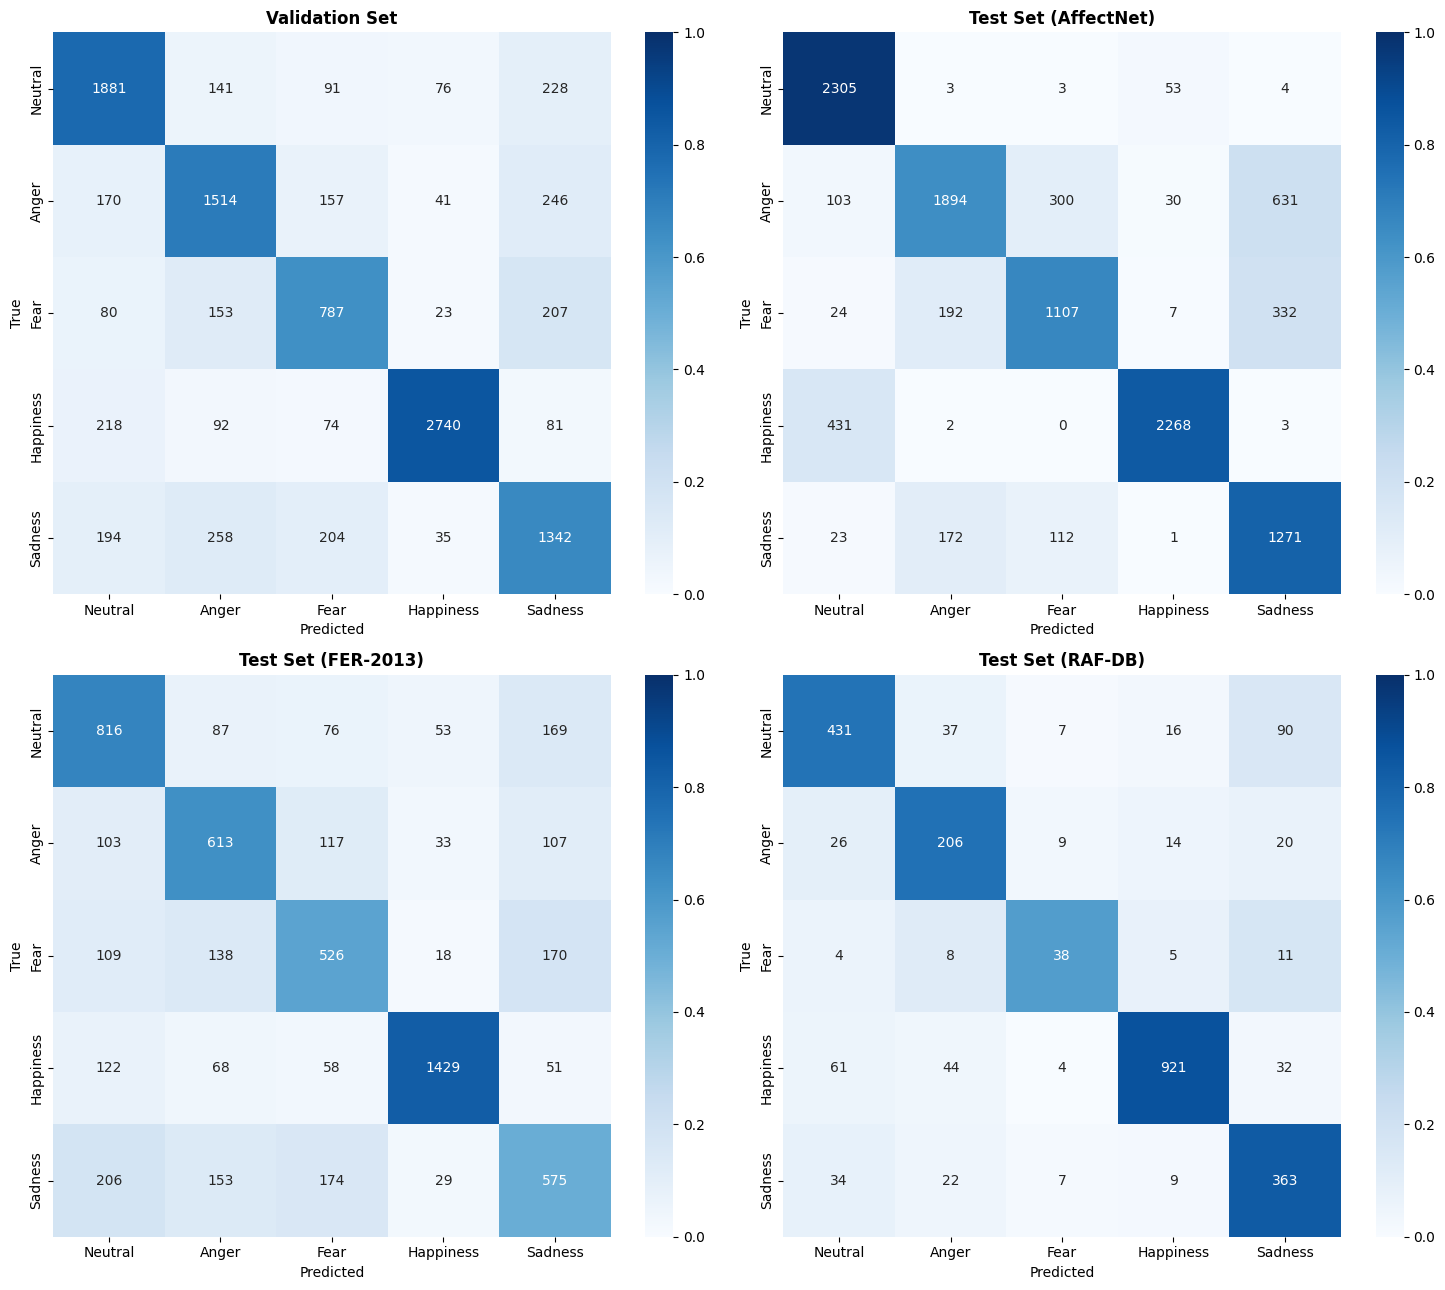

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 13))
axes = axes.flatten()

evals = [
    (val_labels,  val_preds,  "Validation Set"),
    (aff_labels,  aff_preds,  "Test Set (AffectNet)"),
    (fer_labels,  fer_preds,  "Test Set (FER-2013)"),
    (raf_labels,  raf_preds,  "Test Set (RAF-DB)"),
]

for ax, (labels, preds, title) in zip(axes, evals):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
        xticklabels=CFG["class_names"],
        yticklabels=CFG["class_names"],
        vmin=0, vmax=1,
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/confusion_matrices.png", dpi=150)
plt.show()

In [10]:
# Save full model + metadata
torch.save({
    "model_state":  model.state_dict(),
    "class_names":  CFG["class_names"],
    "class_to_idx": train_ds.class_to_idx,
    "img_size":     CFG["img_size"],
    "mean":         IMAGENET_MEAN,
    "std":          IMAGENET_STD,
    "best_val_acc": best_val_acc,
    "cfg":          CFG,
}, f"{CFG['output_dir']}/mobilenetv3_5class_final.pth")

# Save training history as JSON
with open(f"{CFG['output_dir']}/history.json", "w") as f:
    json.dump(history, f, indent=2)

print("Saved:")
print(f"  {CFG['output_dir']}/best_mobilenetv3_5class.pth")
print(f"  {CFG['output_dir']}/mobilenetv3_5class_final.pth")
print(f"  {CFG['output_dir']}/history.json")
print(f"  {CFG['output_dir']}/training_curves.png")
print(f"  {CFG['output_dir']}/confusion_matrices.png")



Saved:
  /kaggle/working/best_mobilenetv3_5class.pth
  /kaggle/working/mobilenetv3_5class_final.pth
  /kaggle/working/history.json
  /kaggle/working/training_curves.png
  /kaggle/working/confusion_matrices.png


## 10. Quick Inference Test


In [11]:
from PIL import Image

def predict_image(image_path: str, model, device=DEVICE):
    img    = Image.open(image_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()
    print(f"Predicted: {CFG['class_names'][pred]}  (conf={probs[pred]:.3f})")
    for name, p in zip(CFG["class_names"], probs):
        bar = "█" * int(p * 30)
        print(f"  {name:20s} {p:.4f}  {bar}")
    return pred, probs

print("Model ready for inference.")
print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")

Model ready for inference.
Best Val Accuracy: 74.90%
